## Time Series Analysis and Forecasting Project


In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller,kpss
from pmdarima import auto_arima 
from statsmodels.tsa.arima.model import ARIMA, ARIMAResults
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.ticker as ticker
formatter = ticker.StrMethodFormatter('{x:,.0f}')
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

**Data Load**

In [2]:
electric_df = pd.read_csv("./Electric_Production.csv", index_col='DATE', parse_dates=True)

In [3]:
electric_df.head()

,IPG2211A2N
DATE,
1985-01-01,72.5052
1985-02-01,70.6720
1985-03-01,62.4502
1985-04-01,57.4714
1985-05-01,55.3151


In [4]:
electric_df.index

DatetimeIndex(['1985-01-01', '1985-02-01', '1985-03-01', '1985-04-01',
               '1985-05-01', '1985-06-01', '1985-07-01', '1985-08-01',
               '1985-09-01', '1985-10-01',
               ...
               '2017-04-01', '2017-05-01', '2017-06-01', '2017-07-01',
               '2017-08-01', '2017-09-01', '2017-10-01', '2017-11-01',
               '2017-12-01', '2018-01-01'],
              dtype='datetime64[ns]', name='DATE', length=397, freq=None)

**Visualizing the Data**

<Axes: title={'center': 'Electricity Production'}, xlabel='DATE'>

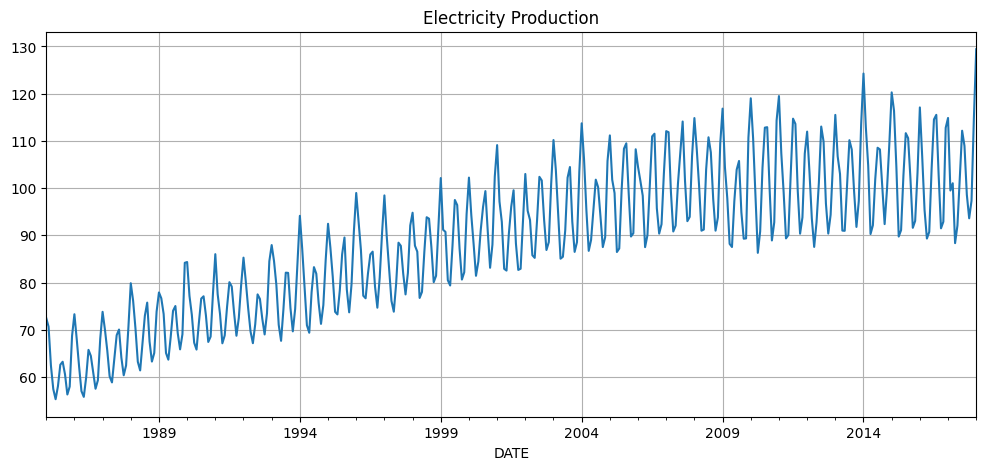

In [5]:
electric_df['IPG2211A2N'].plot(figsize=(12,5), title="Electricity Production", grid=True)

**Seasonal Decompose**

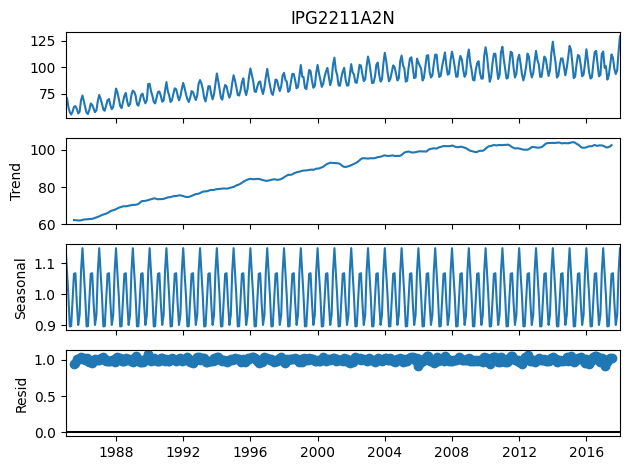

In [6]:
decomp = seasonal_decompose(electric_df['IPG2211A2N'], model='multiplicative') 
decomp.plot()
plt.show()

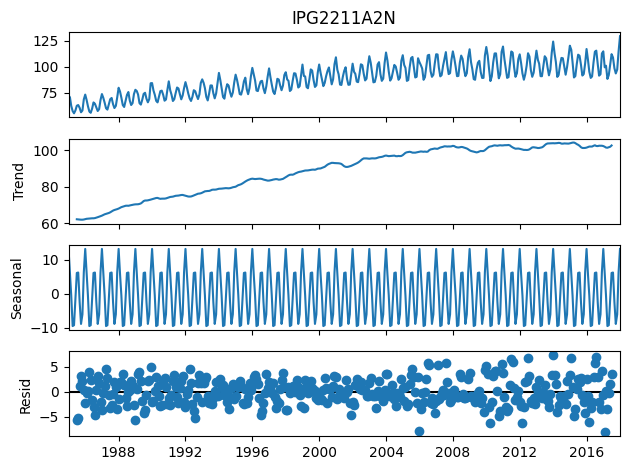

In [7]:
decomp = seasonal_decompose(electric_df['IPG2211A2N'], model='additive') 
decomp.plot()
plt.show()

## PreProcessing Steps

Missing Value

In [8]:
print("\nMissing value count:", electric_df['IPG2211A2N'].isna().sum())


Missing value count: 0


Outlier Deduction

In [9]:
z = np.abs((electric_df.IPG2211A2N - electric_df.IPG2211A2N.mean()) / electric_df.IPG2211A2N.std())
#electric_df["Value_clean"] = np.where(z > 3, electric_df.IPG2211A2N.median(), electric_df.IPG2211A2N)
electric_df[z>3]


,IPG2211A2N
DATE,


**Stationarity checks**

**Augmented Dickey-Fuller Test**

Null hypothesis (H0): The series has a unit root (non-stationary).

Alternative hypothesis (H1): The series is stationary.

In [10]:
adf_result = adfuller(electric_df['IPG2211A2N'], autolag='AIC') 
labels = ['ADF test statistic','p-value','# lags used','# observations']
out = pd.Series(adf_result[0:4],index=labels)
p_val =adf_result[1]
for key,val in adf_result[4].items():
    out[f'critical value ({key})']=val
print(out.to_string())
if p_val<= 0.05:
   print("Strong evidence against the null hypothesis")
   print("Reject the null hypothesis")
   print("Data has no unit root and is stationary")
else:
    print("Weak evidence against the null hypothesis")
    print("Fail to reject the null hypothesis")
    print("Data has a unit root and is non-stationary")

ADF test statistic       -2.256990
p-value                   0.186215
# lags used              15.000000
# observations          381.000000
critical value (1%)      -3.447631
critical value (5%)      -2.869156
critical value (10%)     -2.570827
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-stationary


**KPSS Test**

Null hypothesis (H0): The series is stationary .

Alternative hypothesis (H1): The series is non-stationary.

In [11]:
stat, p_value, lags, crit = kpss(electric_df['IPG2211A2N']) 

print("KPSS Statistic:", stat)
print("p-value:", p_value)
print("Critical Values:", crit)
print("Lags used:", lags)

if p_value < 0.05:
    print("\n Reject the null hypothesis: The series is likely non-stationary.")
else:
    print("\n Fail to reject the null hypothesis: The series is likely stationary.")

KPSS Statistic: 3.5315970094994853
p-value: 0.01
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Lags used: 10

 Reject the null hypothesis: The series is likely non-stationary.


C:\Users\HP\AppData\Local\Temp\ipykernel_18896\3205905751.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p_value, lags, crit = kpss(electric_df['IPG2211A2N'])


**Detrending by Differencing**


<Axes: title={'center': 'Electricity Production After Detrendig'}, xlabel='DATE'>

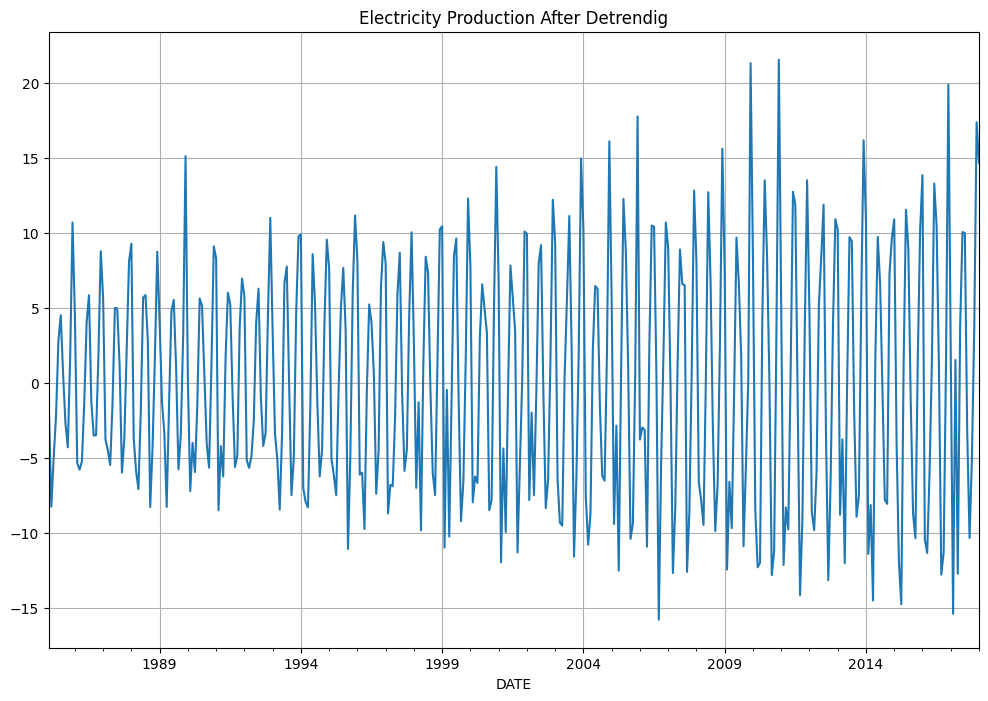

In [12]:
electric_df["IPG2211A2N_diff"] = electric_df["IPG2211A2N"] - electric_df["IPG2211A2N"].shift(1)
electric_df["IPG2211A2N_diff"].dropna().plot(figsize=(12, 8),title="Electricity Production After Detrendig", grid=True)

**ADF Test after Detrending**

In [13]:
adf_result_diff = adfuller(electric_df["IPG2211A2N_diff"].dropna(), autolag='AIC') 
labels = ['ADF test statistic','p-value','# lags used','# observations']
out_diff = pd.Series(adf_result_diff[0:4],index=labels)
p_val =adf_result_diff[1]
for key,val in adf_result_diff[4].items():
    out_diff[f'critical value ({key})']=val
print(out_diff.to_string())
if p_val<= 0.05:
   print("Strong evidence against the null hypothesis")
   print("Reject the null hypothesis")
   print("Data has no unit root and is stationary")
else:
    print("Weak evidence against the null hypothesis")
    print("Fail to reject the null hypothesis")
    print("Data has a unit root and is non-stationary")


ADF test statistic     -7.104891e+00
p-value                 4.077787e-10
# lags used             1.400000e+01
# observations          3.810000e+02
critical value (1%)    -3.447631e+00
critical value (5%)    -2.869156e+00
critical value (10%)   -2.570827e+00
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary


## Model Development

**ARIMA Model**

In [14]:

auto_arima(electric_df['IPG2211A2N_diff'].dropna(),seasonal=False).summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  396
Model:               SARIMAX(4, 0, 2)   Log Likelihood               -1038.180
Date:                Thu, 18 Jun 2026   AIC                           2090.359
Time:                        19:17:50   BIC                           2118.229
Sample:                    02-01-1985   HQIC                          2101.400
                         - 01-01-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8251      0.045     18.221      0.000       0.736       0.914
ar.L2         -0.9761      0.056    -17.545      0.000      -1.085      -0.867
ar.L3         -0.0234      0.056     -0.421      0.674      -0.133       0.086
ar.L4         -0.1513      0.046     -3.280      0.001      -0.242      -0.061
ma.L1         -1.0331      0.018    -57.533      0.000      -1.068      -0.998
ma.L2          0.9783      0.017     55.913      0.000       0.944       1.013
sigma2        10.8608      0.759     14.306      0.000       9.373      12.349
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 6.02
Prob(Q):                              0.89   Prob(JB):                         0.05
Heteroskedasticity (H):               1.91   Skew:                             0.03
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.60
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [15]:
stepwise_fit = auto_arima(electric_df['IPG2211A2N_diff'].dropna(), start_p=0, start_q=0,
                          max_p=2, max_q=2, m=12,
                          seasonal=False,
                          d=None, trace=True,
                          error_action='ignore',   # we don't want to know if an order does not work
                          suppress_warnings=True,  # we don't want convergence warnings
                          stepwise=True)           # set to stepwise

stepwise_fit.summary()

c:\Users\HP\OneDrive\Documents\logicmojo_Datascience_2025\dsenv\Lib\site-packages\pmdarima\arima\_validation.py:62: UserWarning: m (12) set for non-seasonal fit. Setting to 0
  warnings.warn("m (%i) set for non-seasonal fit. Setting to 0" % m)


Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=2748.185, Time=0.03 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=2689.838, Time=0.05 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=2622.550, Time=0.06 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=2623.589, Time=0.07 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=2537.981, Time=0.10 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=2504.076, Time=0.32 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=2102.797, Time=0.51 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=2250.071, Time=0.15 sec
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.77 sec

Best model:  ARIMA(2,0,2)(0,0,0)[0]          
Total fit time: 2.070 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  396
Model:               SARIMAX(2, 0, 2)   Log Likelihood               -1046.398
Date:                Thu, 18 Jun 2026   AIC                           2102.797
Time:                        19:17:54   BIC                           2122.704
Sample:                    02-01-1985   HQIC                          2110.683
                         - 01-01-2018                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9999      0.002    546.449      0.000       0.996       1.003
ar.L2         -0.9994      0.001   -896.334      0.000      -1.002      -0.997
ma.L1         -1.0430      0.017    -61.335      0.000      -1.076      -1.010
ma.L2          0.9745      0.018     55.494      0.000       0.940       1.009
sigma2        11.2953      0.638     17.714      0.000      10.046      12.545
===================================================================================
Ljung-Box (L1) (Q):                   7.72   Jarque-Bera (JB):                25.76
Prob(Q):                              0.01   Prob(JB):                         0.00
Heteroskedasticity (H):               2.21   Skew:                             0.02
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.25
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

**Split the data into train/test sets**

In [16]:
len(electric_df)

397

In [17]:
train = electric_df.iloc[:len(electric_df)-12].dropna()
test = electric_df.iloc[len(electric_df)-12:].dropna()

Fit an ARIMA(2,0,2) Model

In [18]:
model = ARIMA(train['IPG2211A2N_diff'].dropna(),order=(2,0,2))
results = model.fit()
results.summary()

c:\Users\HP\OneDrive\Documents\logicmojo_Datascience_2025\dsenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\HP\OneDrive\Documents\logicmojo_Datascience_2025\dsenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\HP\OneDrive\Documents\logicmojo_Datascience_2025\dsenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\HP\OneDrive\Documents\logicmojo_Datascience_2025\dsenv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:        IPG2211A2N_diff   No. Observations:                  384
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -1000.553
Date:                Thu, 18 Jun 2026   AIC                           2013.106
Time:                        19:18:06   BIC                           2036.810
Sample:                    02-01-1985   HQIC                          2022.508
                         - 01-01-2017                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0989      0.158      0.626      0.532      -0.211       0.409
ar.L1          1.0000      0.002    529.990      0.000       0.996       1.004
ar.L2         -0.9994      0.001   -853.296      0.000      -1.002      -0.997
ma.L1         -1.0471      0.017    -60.249      0.000      -1.081      -1.013
ma.L2          0.9738      0.018     54.688      0.000       0.939       1.009
sigma2        10.4793      0.676     15.503      0.000       9.154      11.804
===================================================================================
Ljung-Box (L1) (Q):                   6.69   Jarque-Bera (JB):                 7.90
Prob(Q):                              0.01   Prob(JB):                         0.02
Heteroskedasticity (H):               1.84   Skew:                            -0.04
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.70
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [19]:
# Obtain predicted values
start=len(train)
end=len(train)+len(test)-1
predictions = results.predict(start=start, end=end, dynamic=False, typ='levels').rename('ARIMA(2,0,2) Predictions')

c:\Users\HP\OneDrive\Documents\logicmojo_Datascience_2025\dsenv\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


In [20]:
# Compare predictions to expected values
for i in range(len(predictions)):
    print(f"predicted={predictions[i]:<11.10}, expected={test['IPG2211A2N_diff'].dropna()[i]}")

predicted=-3.061838671, expected=-15.360399999999998
predicted=-12.50741754, expected=1.5494999999999948
predicted=-9.348083006, expected=-12.686599999999999
predicted=3.251280244, expected=3.7275000000000063
predicted=12.69268049, expected=10.072699999999998
predicted=9.541635934, expected=10.000600000000006
predicted=-3.045261411, expected=-3.2226
predicted=-12.4824814, expected=-10.31580000000001
predicted=-9.339715467, expected=-5.0017
predicted=3.234725701, expected=3.722200000000001
predicted=12.66776381, expected=17.3853
predicted=9.533265154, expected=14.683599999999998


C:\Users\HP\AppData\Local\Temp\ipykernel_18896\1511171032.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"predicted={predictions[i]:<11.10}, expected={test['IPG2211A2N_diff'].dropna()[i]}")


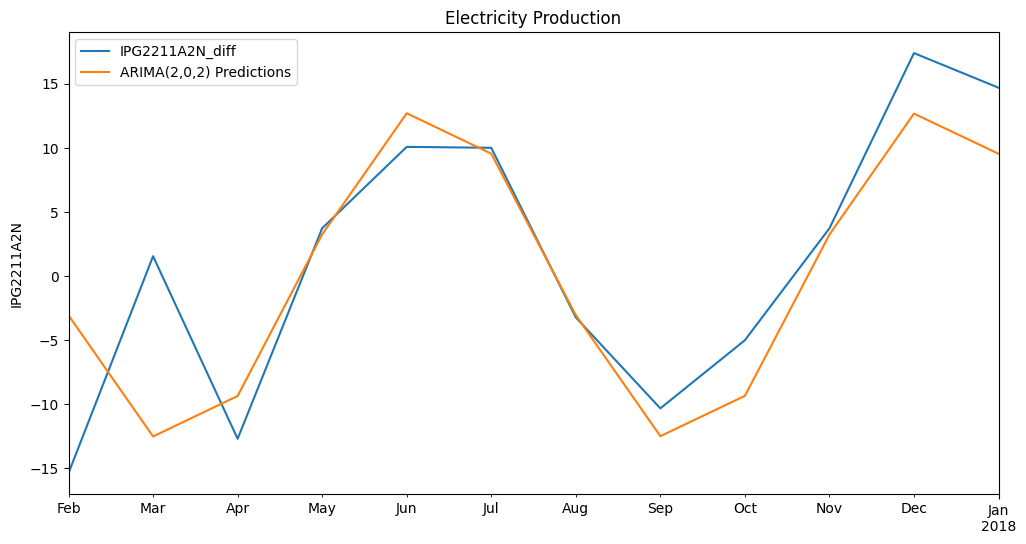

In [21]:
# Plot predictions against known values
title = 'Electricity Production'
ylabel='IPG2211A2N'
xlabel='' # we don't really need a label here

ax = test['IPG2211A2N_diff'].dropna().plot(legend=True,figsize=(12,6),title=title)
predictions.plot(legend=True)
ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)
ax.yaxis.set_major_formatter(formatter);

In [22]:
arima_mse = mean_squared_error(test['IPG2211A2N_diff'].dropna(), predictions)
print(f'ARIMA(2,0,2) MSE Error: {arima_mse:11.10}')

ARIMA(2,0,2) MSE Error: 36.65516931


In [23]:
mape_error = mean_absolute_percentage_error(test['IPG2211A2N_diff'].dropna(), predictions)
print(f'ARIMA(2,0,2) MAPE Error: {mape_error:11.10}')

ARIMA(2,0,2) MAPE Error: 1.037910651


In [24]:

mae_arima = mean_absolute_error(test['IPG2211A2N_diff'].dropna(), predictions)
print(f'ARIMA(2,0,2) MAE Error: {mae_arima:11.10}')

ARIMA(2,0,2) MAE Error: 4.190545081


In [25]:
from statsmodels.tools.eval_measures import rmse

arima_rmse = rmse(test['IPG2211A2N_diff'].dropna(), predictions)
print(f'ARIMA(2,0,2) RMSE Error: {arima_rmse:11.10}')

ARIMA(2,0,2) RMSE Error:  6.05435127


Retrain the model on the full data, and forecast the future

In [26]:
model = ARIMA(electric_df['IPG2211A2N_diff'].dropna(),order=(2,0,2))
results = model.fit()
fcast = results.predict(len(electric_df),len(electric_df)+11,typ='levels').rename('ARIMA(2,0,2) Forecast')

c:\Users\HP\OneDrive\Documents\logicmojo_Datascience_2025\dsenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\HP\OneDrive\Documents\logicmojo_Datascience_2025\dsenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\HP\OneDrive\Documents\logicmojo_Datascience_2025\dsenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\HP\OneDrive\Documents\logicmojo_Datascience_2025\dsenv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c

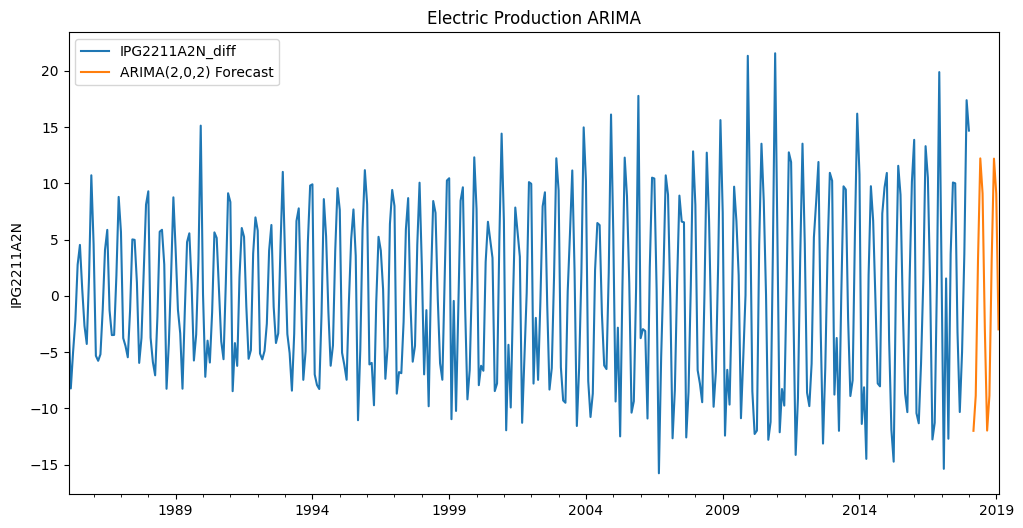

In [27]:
# Plot predictions against known values
title = 'Electric Production ARIMA'
ylabel='IPG2211A2N'
xlabel='' 

ax = electric_df['IPG2211A2N_diff'].dropna().plot(legend=True,figsize=(12,6),title=title)
fcast.plot(legend=True)
ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)
ax.yaxis.set_major_formatter(formatter);

**SARIMA MODEL**

Fitting the Model

In [28]:
p, d, q = 1, 1, 1
P, D, Q, s = 1, 1, 1, 12

model = SARIMAX(electric_df['IPG2211A2N_diff'].dropna(), order=(p, d, q), seasonal_order=(P, D, Q, s))
results_sarima = model.fit()

c:\Users\HP\OneDrive\Documents\logicmojo_Datascience_2025\dsenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\HP\OneDrive\Documents\logicmojo_Datascience_2025\dsenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


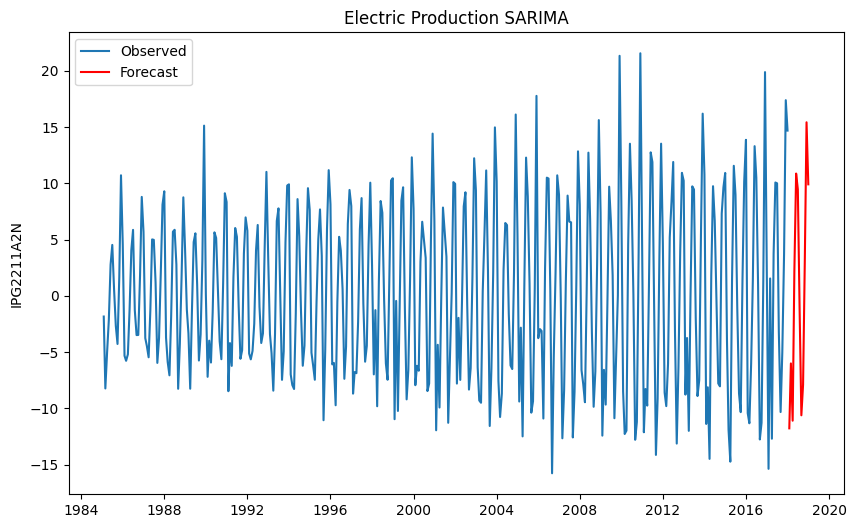

In [29]:
forecast_periods = 12
forecast_sarima = results_sarima.forecast(steps=forecast_periods)

plt.figure(figsize=(10, 6))
plt.plot(electric_df['IPG2211A2N_diff'].dropna(), label='Observed')
plt.plot(forecast_sarima, label='Forecast', color='red')
plt.title('Electric Production SARIMA')
#plt.xlabel("Date")
plt.ylabel("IPG2211A2N")
plt.legend()
plt.show()

In [30]:
observed = electric_df['IPG2211A2N_diff'].dropna().tail(forecast_periods)

mae_sarima = mean_absolute_error(observed, forecast_sarima)
mse_sarima = mean_squared_error(observed, forecast_sarima)
rmse_sarima = rmse(observed, forecast_sarima)

print("MAE SARIMA:", mae_sarima)
print("MSE SARIMA:", mse_sarima)
print("RMSE SARIMA:", rmse_sarima)

MAE SARIMA: 2.3347885114899163
MSE SARIMA: 9.60958121840702
RMSE SARIMA: 3.099932453845893


**Exponential Smoothing**

In [31]:
exp_smooth_model = ExponentialSmoothing(electric_df['IPG2211A2N_diff'].dropna(), trend="add", seasonal=None)
exp_fitted = exp_smooth_model.fit(optimized=True)


c:\Users\HP\OneDrive\Documents\logicmojo_Datascience_2025\dsenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [32]:
forecast_periods = 12
forecast_exp_smooth = exp_fitted.forecast(steps=forecast_periods)
print(forecast_exp_smooth)

2018-02-01    0.328254
2018-03-01    0.329184
2018-04-01    0.330114
2018-05-01    0.331043
2018-06-01    0.331973
2018-07-01    0.332903
2018-08-01    0.333832
2018-09-01    0.334762
2018-10-01    0.335692
2018-11-01    0.336621
2018-12-01    0.337551
2019-01-01    0.338481
Freq: MS, dtype: float64


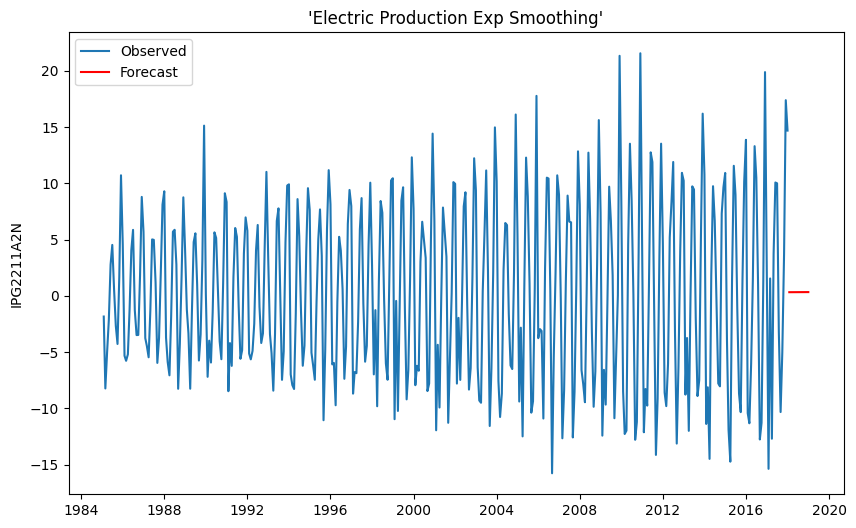

In [33]:
forecast_periods = 12
forecast_exp_smooth = exp_fitted.forecast(steps=forecast_periods)

plt.figure(figsize=(10, 6))
plt.plot(electric_df['IPG2211A2N_diff'].dropna(), label='Observed')
plt.plot(forecast_exp_smooth, label='Forecast', color='red')
plt.title("'Electric Production Exp Smoothing'")
#plt.xlabel("Date")
plt.ylabel("IPG2211A2N")
plt.legend()
plt.show()

In [34]:
observed_exp = electric_df['IPG2211A2N_diff'].dropna().tail(forecast_periods)

mae_exp_smooth = mean_absolute_error(observed_exp, forecast_exp_smooth)
mse_exp_smooth  = mean_squared_error(observed_exp, forecast_exp_smooth)
rmse_exp_smooth  = rmse(observed_exp, forecast_exp_smooth)

print("MAE Exp Smooth:", mae_exp_smooth)
print("MSE Exp Smooth:", mse_exp_smooth)
print("RMSE Exp Smooth:", rmse_exp_smooth)

MAE Exp Smooth: 8.921116509861777
MSE Exp Smooth: 106.61505847044798
RMSE Exp Smooth: 10.325456816550442


**Holt Winters Method**

In [35]:
# additive trend and seasonality

electric_df['IPG2211A2N_add'] = ExponentialSmoothing(electric_df['IPG2211A2N_diff'].dropna(), trend='add', seasonal='add', seasonal_periods=12).fit().fittedvalues.shift(-1)

c:\Users\HP\OneDrive\Documents\logicmojo_Datascience_2025\dsenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


<Axes: title={'center': 'Electric Production over time'}, xlabel='DATE'>

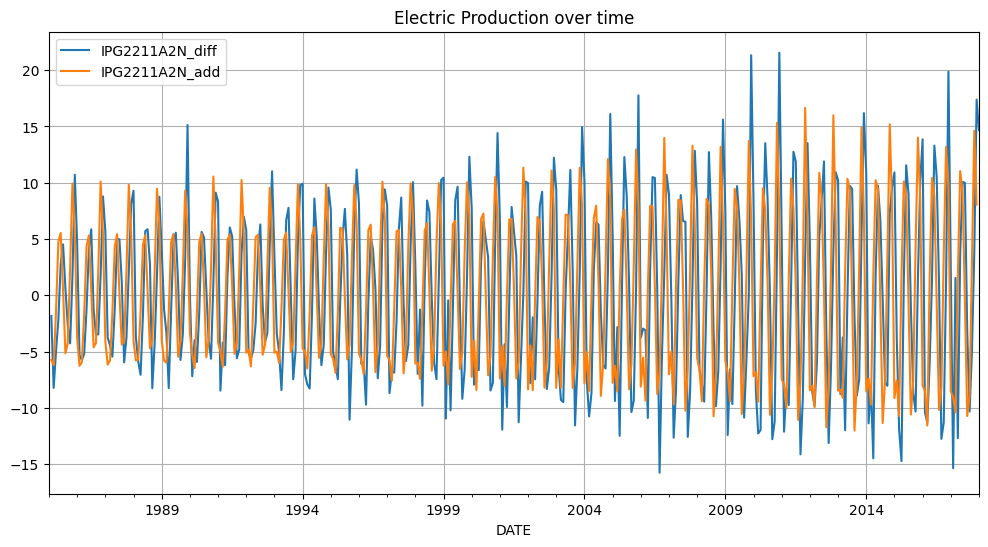

In [36]:
electric_df[['IPG2211A2N_diff', 'IPG2211A2N_add']].plot(figsize=(12,6), grid=True, title='Electric Production over time')

In [37]:
hw_model = ExponentialSmoothing(electric_df['IPG2211A2N_diff'].dropna(), trend='add', seasonal='add', seasonal_periods=12).fit()

c:\Users\HP\OneDrive\Documents\logicmojo_Datascience_2025\dsenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [38]:
forecast_hw = hw_model.forecast(steps=forecast_periods)
print(forecast_hw)

2018-02-01    -9.971777
2018-03-01    -6.817254
2018-04-01   -10.873115
2018-05-01     2.033787
2018-06-01    10.839491
2018-07-01     9.364075
2018-08-01    -0.946380
2018-09-01   -10.631899
2018-10-01    -8.040860
2018-11-01     3.262417
2018-12-01    15.211210
2019-01-01     8.061572
Freq: MS, dtype: float64


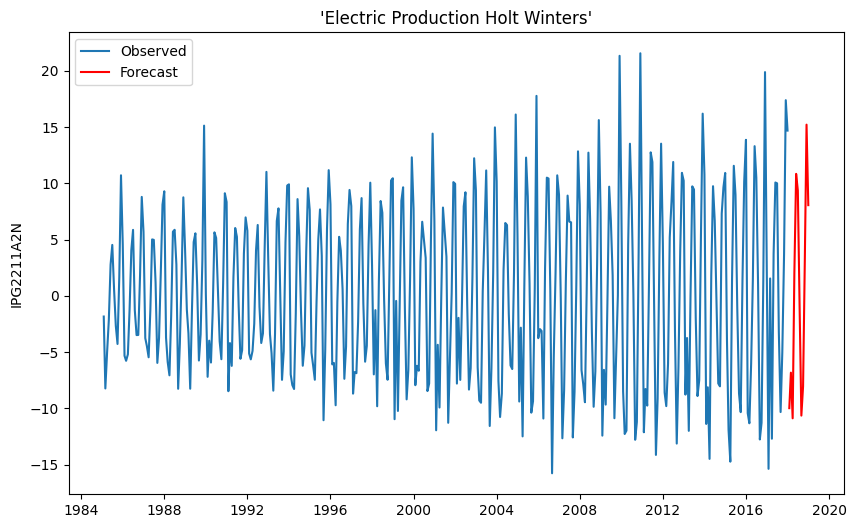

In [39]:
forecast_periods = 12


plt.figure(figsize=(10, 6))
plt.plot(electric_df['IPG2211A2N_diff'].dropna(), label='Observed')
plt.plot(forecast_hw, label='Forecast', color='red')
plt.title("'Electric Production Holt Winters'")
#plt.xlabel("Date")
plt.ylabel("IPG2211A2N")
plt.legend()
plt.show()

In [40]:
observed_hw = electric_df['IPG2211A2N_diff'].dropna().tail(forecast_periods)

mae_hw = mean_absolute_error(observed_hw, forecast_hw)
mse_hw  = mean_squared_error(observed_hw, forecast_hw)
rmse_hw= rmse(observed_hw, forecast_hw)

print("MAE HW:", mae_hw)
print("MSE HW:", mse_hw)
print("RMSE HW:", rmse_hw)

MAE HW: 2.796106060924135
MSE HW: 14.124772823028687
RMSE HW: 3.758293871297013


**Comparison of Methods**

In [41]:

comparison = pd.DataFrame({
    'Method': ['AIRIMA','SARIMA','Exponential Smoothing','Holt Winters'],
    'MAE Score': [mae_arima,mae_sarima,mae_exp_smooth,mae_hw],
    'MSE Score': [arima_mse,mse_sarima,mse_exp_smooth,mse_hw],
    'RMSE Score': [arima_rmse,rmse_sarima,rmse_exp_smooth,rmse_hw]})
comparison = comparison.sort_values('MAE Score')
print(comparison.to_string(index=False))

               Method  MAE Score  MSE Score  RMSE Score
               SARIMA   2.334789   9.609581    3.099932
         Holt Winters   2.796106  14.124773    3.758294
               AIRIMA   4.190545  36.655169    6.054351
Exponential Smoothing   8.921117 106.615058   10.325457


Time Series Forecasting using LSTM

In [65]:
import math
from sklearn.preprocessing import MinMaxScaler

# Train test split
training_data_len = math.ceil(len(electric_df) * .8)
print(training_data_len)

# Splitting the dataset
train_data = electric_df[:training_data_len].iloc[:, :1]
test_data = electric_df[training_data_len:].iloc[:, :1]
print(train_data.shape, test_data.shape)

# Selecting IPG2211A2N values
dataset_train = train_data.IPG2211A2N.values
# Reshaping 1D to 2D array
dataset_train = np.reshape(dataset_train, (-1, 1))
print(dataset_train.shape)

# Selecting IPG2211A2N  values
dataset_test = test_data.IPG2211A2N.values
# Reshaping 1D to 2D array
dataset_test = np.reshape(dataset_test, (-1, 1))
print(dataset_test.shape)

scaler = MinMaxScaler(feature_range=(0, 1))
# Scaling dataset
scaled_train = scaler.fit_transform(dataset_train)
print(scaled_train[:5])

# Normalizing values between 0 and 1
scaled_test = scaler.fit_transform(dataset_test)
print(scaled_test[:5])

318
(318, 1) (79, 1)
(318, 1)
(79, 1)
[[0.26787164]
 [0.23930506]
 [0.11118556]
 [0.03360141]
 [0.        ]]
[[0.6487782 ]
 [0.62222987]
 [0.28470998]
 [0.06690849]
 [0.14941861]]


In [66]:
# Create sequences and labels for training data
sequence_length = 50  # Number of time steps to look back
X_train, y_train = [], []
for i in range(len(scaled_train) - sequence_length):
    X_train.append(scaled_train[i:i + sequence_length])
    y_train.append(scaled_train[i + sequence_length])  # Predicting the value right after the sequence
X_train, y_train = np.array(X_train), np.array(y_train)

# Convert data to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
print(X_train.shape, y_train.shape)

# Create sequences and labels for testing data
sequence_length = 30  # Number of time steps to look back
X_test, y_test = [], []
for i in range(len(scaled_test) - sequence_length):
    X_test.append(scaled_test[i:i + sequence_length])
    y_test.append(scaled_test[i + sequence_length])  # Predicting the value right after the sequence
X_test, y_test = np.array(X_test), np.array(y_test)

# Convert data to PyTorch tensors
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)
print(X_test.shape, y_test.shape)

torch.Size([268, 50, 1]) torch.Size([268, 1])
torch.Size([49, 30, 1]) torch.Size([49, 1])


In [69]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.linear(out[:, -1, :])
        return out

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

input_size = 1
num_layers = 3  # Increased number of layers
hidden_size = 128  # Increased number of hidden units
output_size = 1
dropout = 0.2  # Added dropout for regularization

model = LSTMModel(input_size, hidden_size, num_layers, output_size, dropout).to(device)
loss_fn = nn.MSELoss(reduction='mean')
optimizer = optim.Adam(model.parameters(), lr=1e-3)  # Learning rate

batch_size = 32  # Adjusted batch size
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

num_epochs = 100  # Increased number of epochs
train_hist = []
test_hist = []

for epoch in range(num_epochs):
    total_loss = 0.0
    model.train()
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        predictions = model(batch_X)
        loss = loss_fn(predictions, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)
    train_hist.append(average_loss)

    model.eval()
    with torch.no_grad():
        total_test_loss = 0.0

        for batch_X_test, batch_y_test in test_loader:
            batch_X_test, batch_y_test = batch_X_test.to(device), batch_y_test.to(device)
            predictions_test = model(batch_X_test)
            test_loss = loss_fn(predictions_test, batch_y_test)

            total_test_loss += test_loss.item()

        average_test_loss = total_test_loss / len(test_loader)
        test_hist.append(average_test_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}] - Training Loss: {average_loss:.4f}, Test Loss: {average_test_loss:.4f}')

cpu
Epoch [10/100] - Training Loss: 0.0171, Test Loss: 0.0639
Epoch [20/100] - Training Loss: 0.0146, Test Loss: 0.0643
Epoch [30/100] - Training Loss: 0.0150, Test Loss: 0.0628
Epoch [40/100] - Training Loss: 0.0157, Test Loss: 0.0688
Epoch [50/100] - Training Loss: 0.0151, Test Loss: 0.0613
Epoch [60/100] - Training Loss: 0.0178, Test Loss: 0.0622
Epoch [70/100] - Training Loss: 0.0153, Test Loss: 0.0612
Epoch [80/100] - Training Loss: 0.0152, Test Loss: 0.0630
Epoch [90/100] - Training Loss: 0.0167, Test Loss: 0.0608
Epoch [100/100] - Training Loss: 0.0137, Test Loss: 0.0564


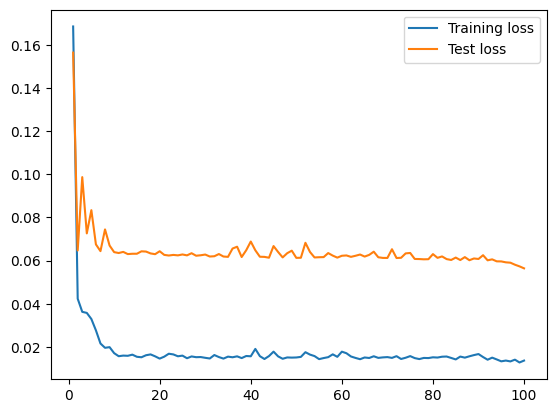

In [70]:
x = np.linspace(1,num_epochs,num_epochs)
plt.plot(x,train_hist,scalex=True, label="Training loss")
plt.plot(x, test_hist, label="Test loss")
plt.legend()
plt.show()

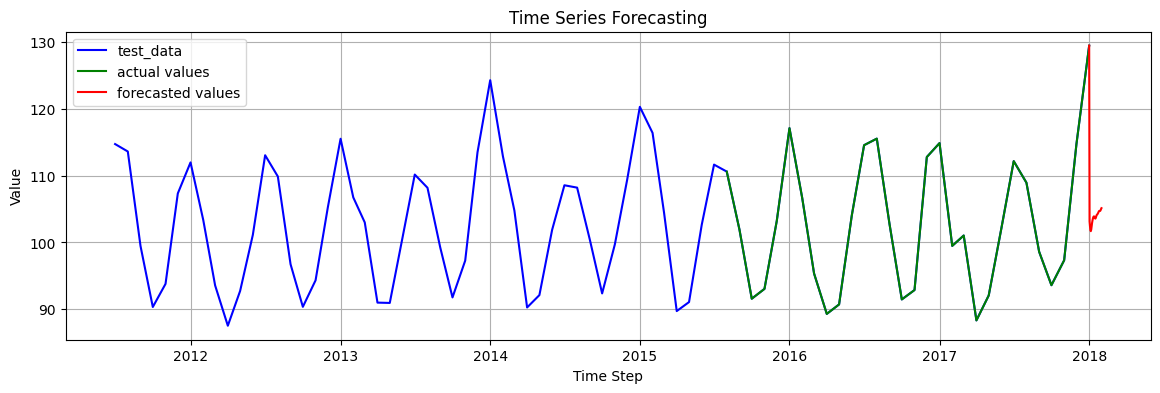

RMSE: 0.2336


In [72]:
num_forecast_steps = 30
sequence_to_plot = X_test.squeeze().cpu().numpy()
historical_data = sequence_to_plot[-1]

forecasted_values = []
with torch.no_grad():
    for _ in range(num_forecast_steps):
        historical_data_tensor = torch.as_tensor(historical_data).view(1, -1, 1).float().to(device)
        predicted_value = model(historical_data_tensor).cpu().numpy()[0, 0]
        forecasted_values.append(predicted_value)
        historical_data = np.roll(historical_data, shift=-1)
        historical_data[-1] = predicted_value

last_date = test_data.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(1), periods=30)

plt.rcParams['figure.figsize'] = [14, 4]
plt.plot(test_data.index[-100:], test_data.IPG2211A2N[-100:], label="test_data", color="b")
plt.plot(test_data.index[-30:], test_data.IPG2211A2N[-30:], label='actual values', color='green')
plt.plot(test_data.index[-1:].append(future_dates), np.concatenate([test_data.IPG2211A2N[-1:], scaler.inverse_transform(np.array(forecasted_values).reshape(-1, 1)).flatten()]), label='forecasted values', color='red')

plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.title('Time Series Forecasting')
plt.grid(True)
plt.show()

# Evaluate the model and calculate RMSE  score
model.eval()
with torch.no_grad():
    test_predictions = []
    for batch_X_test in X_test:
        batch_X_test = batch_X_test.to(device).unsqueeze(0)  # Add batch dimension
        test_predictions.append(model(batch_X_test).cpu().numpy().flatten()[0])

test_predictions = np.array(test_predictions)

# Calculate RMSE and R² score
rmse_lstm = np.sqrt(mean_squared_error(y_test.cpu().numpy(), test_predictions))

print(f'RMSE: {rmse_lstm:.4f}')